### [Combining Instrumental Variables and Double Machine Learning for Robust Causal Inference](https://medium.com/causal-inference-methods-models-and-applications/combining-instrumental-variables-and-double-machine-learning-for-robust-causal-inference-c5fbf20de7bf)



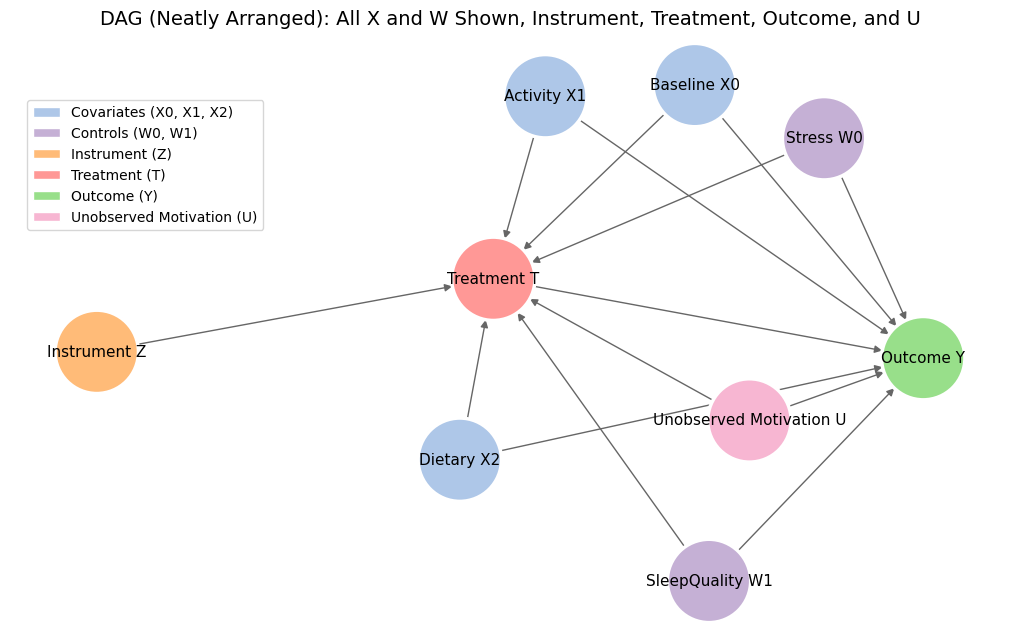

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings("ignore")

# Create DAG
G = nx.DiGraph()

# Nodes
nodes = [
    "Instrument Z",
    "Baseline X0", "Activity X1", "Dietary X2",
    "Stress W0", "SleepQuality W1",
    "Unobserved Motivation U",
    "Treatment T",
    "Outcome Y"
]
G.add_nodes_from(nodes)

# Edges
edges = [
    ("Instrument Z", "Treatment T"),
    ("Baseline X0", "Treatment T"), ("Activity X1", "Treatment T"), ("Dietary X2", "Treatment T"),
    ("Stress W0", "Treatment T"), ("SleepQuality W1", "Treatment T"),
    ("Baseline X0", "Outcome Y"), ("Activity X1", "Outcome Y"), ("Dietary X2", "Outcome Y"),
    ("Stress W0", "Outcome Y"), ("SleepQuality W1", "Outcome Y"),
    ("Treatment T", "Outcome Y"),
    ("Unobserved Motivation U", "Treatment T"), ("Unobserved Motivation U", "Outcome Y")
]
G.add_edges_from(edges)

# Colors by category
colors = {
    "Instrument Z": "#ffbb78",   # Instrument
    "Baseline X0": "#aec7e8", "Activity X1": "#aec7e8", "Dietary X2": "#aec7e8",  # Covariates
    "Stress W0": "#c5b0d5", "SleepQuality W1": "#c5b0d5",  # Controls
    "Unobserved Motivation U": "#f7b6d2",  # Unobserved
    "Treatment T": "#ff9896",  # Treatment
    "Outcome Y": "#98df8a"     # Outcome
}
color_list = [colors[n] for n in G.nodes()]

# Define positions for nodes
pos = nx.spring_layout(G, k=0.8, iterations=50) # You can try different layouts, e.g., nx.circular_layout(G)

# Draw DAG
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_size=3600, node_color=color_list,
        font_size=11,# font_weight='bold',
        arrowsize=11, edge_color="#666666", linewidths=0.8)
nx.draw_networkx_nodes(G, pos, node_size=3600, node_color=color_list, edgecolors='white', linewidths=2.5)

plt.title("DAG (Neatly Arranged): All X and W Shown, Instrument, Treatment, Outcome, and U", fontsize=14)

# Legend
legend_labels = {
    "Covariates (X0, X1, X2)": "#aec7e8",
    "Controls (W0, W1)": "#c5b0d5",
    "Instrument (Z)": "#ffbb78",
    "Treatment (T)": "#ff9896",
    "Outcome (Y)": "#98df8a",
    "Unobserved Motivation (U)": "#f7b6d2"
}
legend_patches = [Patch(facecolor=c, edgecolor='white', label=lab) for lab, c in legend_labels.items()]
plt.legend(handles=legend_patches, bbox_to_anchor=(0.01, 0.9), loc='upper left')
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pandas as pd

true_effect = 2.0
np.random.seed(42)
n = 5000

# Generate covariates (X) and controls (W)
X = np.random.normal(0, 1, (n, 3))   # Covariates: Baseline, Activity, Dietary
W = np.random.normal(0, 1, (n, 2))   # Controls: Stress, Sleep Quality

# Instrument
Z = np.random.binomial(1, 0.5, size=n)  # Instrument: motivational text reminders

# Treatment: influenced by instrument and baseline health risk
T = 0.5 * Z + 1.5 * X[:, 0] + np.random.normal(0, 1, size=n)

# Outcome: depends on treatment, activity, and error correlated with baseline
error_Y = np.random.normal(0, 1, size=n) + 0.8 * X[:, 0]
Y = true_effect * T + 0.5 * X[:, 1] + error_Y

# Create DataFrame with descriptive column names
df_hd = pd.DataFrame({
    'Baseline': X[:, 0],          # Baseline health risk
    'Activity': X[:, 1],          # Physical activity level
    'Dietary': X[:, 2],           # Dietary quality
    'Stress': W[:, 0],            # Stress level
    'SleepQuality': W[:, 1],      # Sleep quality
    'Treatment': T,               # Coaching program engagement
    'Outcome': Y,                 # Wellness improvement
    'Instrument': Z               # Motivational text reminders
})

print("Updated DataFrame with W included (first 5 rows):")
display(df_hd.head())

Updated DataFrame with W included (first 5 rows):


,Baseline,Activity,Dietary,Stress,SleepQuality,Treatment,Outcome,Instrument
0,0.496714,-0.138264,0.647689,-0.143423,-0.032656,1.534911,2.931539,1
1,1.523030,-0.234153,-0.234137,0.064295,0.946861,1.592548,3.841512,1
2,1.579213,0.767435,-0.469474,-0.747217,-0.846347,1.549821,5.751520,0
3,0.542560,-0.463418,-0.465730,1.236620,-0.462645,2.237177,5.688446,1
4,0.241962,-1.913280,-1.724918,-1.263035,-0.485130,2.239843,3.870045,0


In [3]:
import numpy as np
import statsmodels.api as sm

# 2. Naive OLS regression of Y on T (ignoring endogeneity)
X_ols = sm.add_constant(T)
ols_model = sm.OLS(Y, X_ols).fit()

# 3. Print results
estimated_effect = ols_model.params[1]
print("True Effect:", true_effect)
print("Naive OLS Estimated Effect:", estimated_effect)
print("OLS Summary:\n")
display(ols_model.summary())

True Effect: 2.0
Naive OLS Estimated Effect: 2.3493219183422074
OLS Summary:



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 6.507e+04
Date:                Tue, 06 Jan 2026   Prob (F-statistic):               0.00
Time:                        08:41:15   Log-Likelihood:                -8017.6
No. Observations:                5000   AIC:                         1.604e+04
Df Residuals:                    4998   BIC:                         1.605e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1105      0.017     -6.438      0.000      -0.144      -0.077
x1             2.3493      0.009    255.086      0.000       2.331       2.367
==============================================================================
Omnibus:                        1.366   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.505   Jarque-Bera (JB):                1.369
Skew:                           0.007   Prob(JB):                        0.504
Kurtosis:                       2.920   Cond. No.                         1.89
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [4]:
%pip install --quiet dowhy econml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 16.2 MB/s eta 0:00:00


In [5]:
import dowhy
from dowhy import CausalModel

# Define the causal model using updated DataFrame and column names
model_iv = CausalModel(
    data=df_hd,
    treatment='Treatment',          # T
    outcome='Outcome',              # Y
    instruments='Instrument',       # Z
    common_causes=['Baseline', 'Activity', 'Dietary', 'Stress', 'SleepQuality']
)
# Identify the estimand
identified_estimand = model_iv.identify_effect(proceed_when_unidentifiable=True)

# Estimate effect using IV (2SLS)
est_iv = model_iv.estimate_effect(
    identified_estimand,
    method_name="iv.instrumental_variable"
)
# Point estimate
ate_iv = est_iv.value
# 95% confidence interval from DoWhy
ci_low, ci_high = est_iv.get_confidence_intervals(confidence_level=0.95)

print("DoWhy IV (2SLS) estimate:", ate_iv)
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

DoWhy IV (2SLS) estimate: 2.01192452325311
95% CI: [1.8330, 2.2122]


In [6]:
from econml.iv.dml import DMLIV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neural_network import MLPRegressor

# Define different model configurations
models = {
    "Linear": {
        "model_y_xw": LinearRegression(),
        "model_t_xw": LinearRegression(),
        "model_t_xwz": LinearRegression()
    },
    "RandomForest": {
        "model_y_xw": RandomForestRegressor(n_estimators=100, max_depth=5),
        "model_t_xw": RandomForestRegressor(n_estimators=100, max_depth=5),
        "model_t_xwz": RandomForestRegressor(n_estimators=100, max_depth=5)
    },
    "GradientBoosting": {
        "model_y_xw": GradientBoostingRegressor(n_estimators=100),
        "model_t_xw": GradientBoostingRegressor(n_estimators=100),
        "model_t_xwz": GradientBoostingRegressor(n_estimators=100)
    },
    "Lasso": {
        "model_y_xw": Lasso(alpha=0.01),
        "model_t_xw": Lasso(alpha=0.01),
        "model_t_xwz": Lasso(alpha=0.01)
    },
    "NeuralNet": {
        "model_y_xw": MLPRegressor(hidden_layer_sizes=(50,), max_iter=500),
        "model_t_xw": MLPRegressor(hidden_layer_sizes=(50,), max_iter=500),
        "model_t_xwz": MLPRegressor(hidden_layer_sizes=(50,), max_iter=500)
    }
}

# Fit each model and store CATE estimates
cate_results = {}
for name, m in models.items():
    dmliv = DMLIV(
        model_y_xw=m["model_y_xw"],
        model_t_xw=m["model_t_xw"],
        model_t_xwz=m["model_t_xwz"],
        model_final=LinearRegression(),
        discrete_treatment=False
    )
    dmliv.fit(Y=Y, T=T, Z=Z, X=X, W=W)
    cate_results[name] = dmliv.effect(X)
    print(f"{name} (first 10 CATE):", cate_results[name][:10])

Linear (first 10 CATE): [1.68510155 1.4542139  1.53730453 1.85343132 2.11115984 2.09354398
 1.98744904 2.35293187 2.42543588 1.87602099]
RandomForest (first 10 CATE): [1.78849228 1.75599601 1.8100656  2.01532769 2.33187625 2.07718687
 1.89614196 2.39809076 2.40838438 2.01164103]
GradientBoosting (first 10 CATE): [1.79973352 1.84460225 2.02448987 1.87843033 1.81545803 1.74926818
 1.56708    2.10603424 2.09420878 1.84393876]
Lasso (first 10 CATE): [1.80606732 1.5725373  1.67551778 2.02732707 2.35037192 2.27253188
 2.11815116 2.61835796 2.69182051 2.04718641]
NeuralNet (first 10 CATE): [1.24994308 1.2107605  1.19956962 1.38450568 1.62018642 1.46675151
 1.39271634 1.59025138 1.6019943  1.39198136]


True Effect: 2.0
Linear: mean=2.001, std=0.419
RandomForest: mean=2.039, std=0.301
GradientBoosting: mean=1.919, std=0.199
Lasso: mean=2.181, std=0.484
NeuralNet: mean=1.392, std=0.184


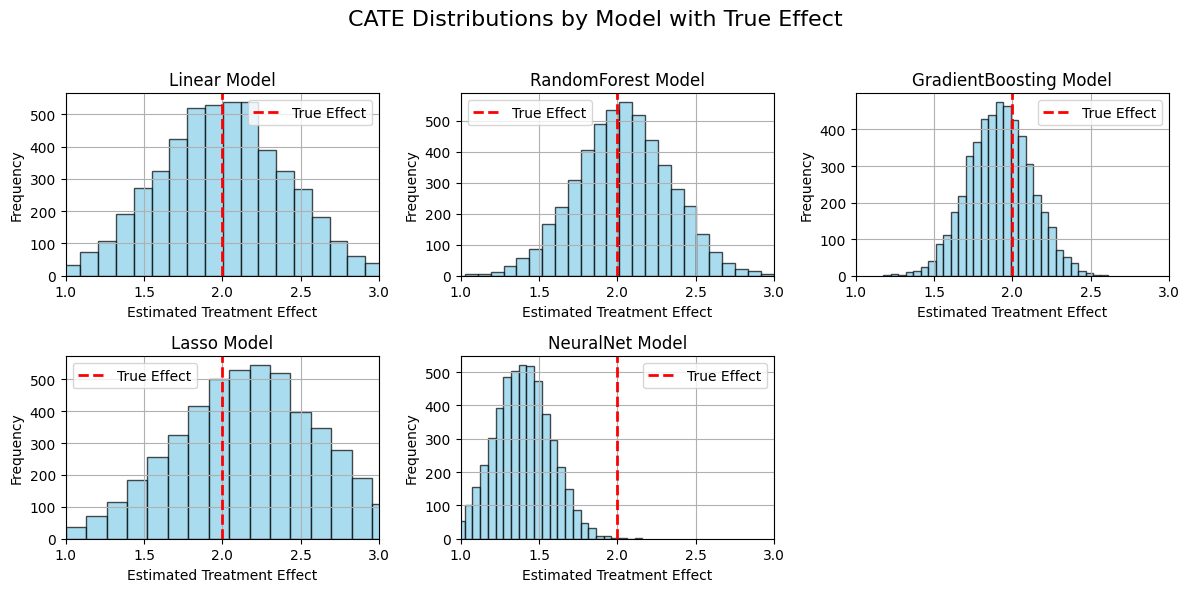

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle('CATE Distributions by Model with True Effect', fontsize=16)

axes = axes.flatten()

for i, (name, cate) in enumerate(cate_results.items()):
    axes[i].hist(cate, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].axvline(x=true_effect, color='red', linestyle='--', linewidth=2, label='True Effect')
    axes[i].set_title(f'{name} Model')
    axes[i].set_xlim(1,3)
    axes[i].set_xlabel('Estimated Treatment Effect')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True)

# Hide the last empty subplot if models < 6
if len(cate_results) < len(axes):
    axes[-1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('cate_histograms_3x2.png')

# Print summary statistics for each model
print("True Effect:", true_effect)
for name, cate in cate_results.items():
    print(f"{name}: mean={np.mean(cate):.3f}, std={np.std(cate):.3f}")

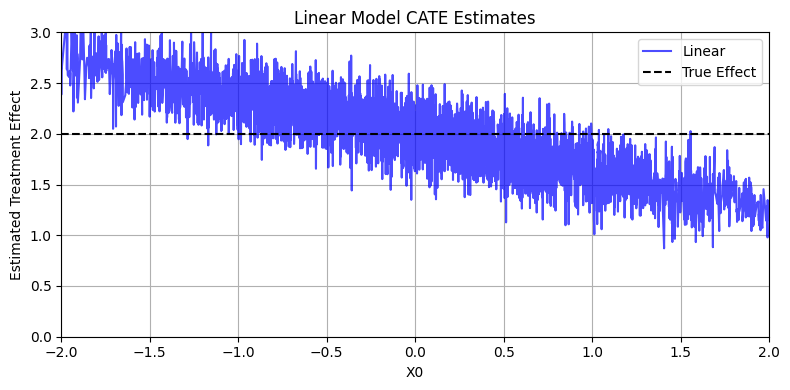

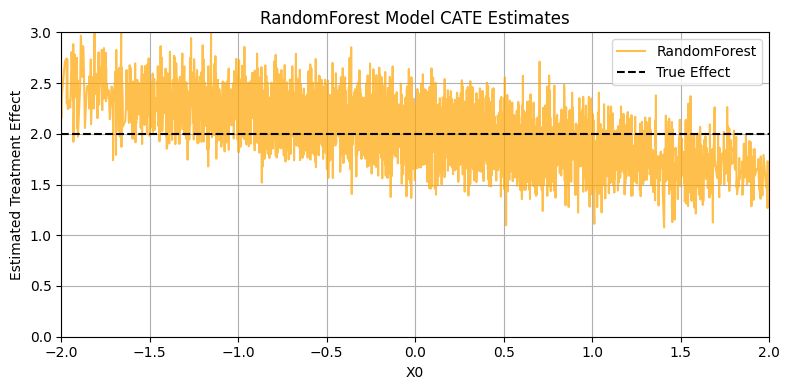

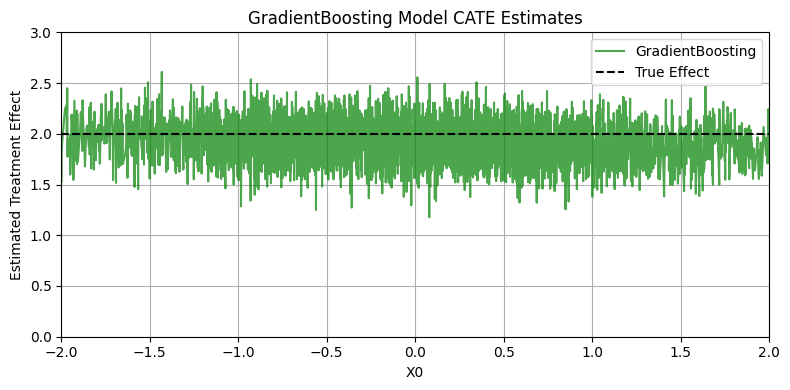

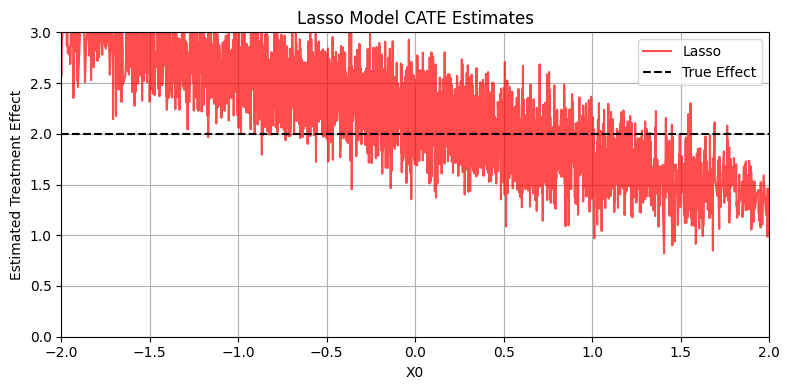

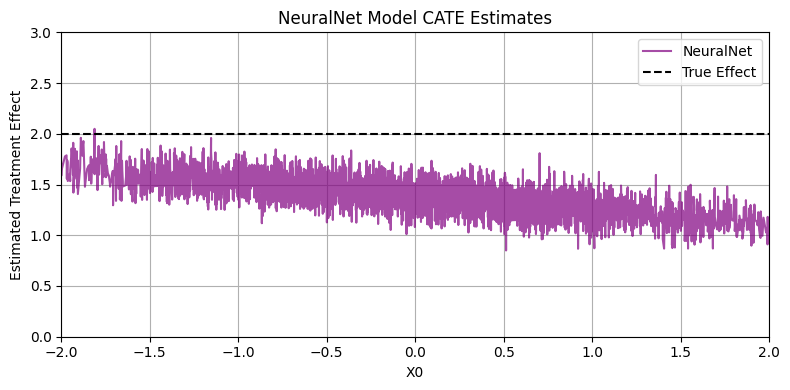

In [8]:
def viz_X1(name):
    # Visualization: Compare all models vs X1
    cate = cate_results[name]
    sorted_idx = np.argsort(X[:, 0])
    X1_sorted = X[:, 0][sorted_idx]
    plt.figure(figsize=(8, 4))
    plt.plot(X1_sorted, cate[sorted_idx], label=name, alpha=0.7,
            color=model_colors.get(name, None))
    plt.axhline(y=2.0, color='black', linestyle='--', label='True Effect')
    plt.xlabel('X0')
    plt.ylabel('Estimated Treatment Effect')
    plt.title(name + ' Model CATE Estimates')
    plt.legend()
    plt.xlim(-2,2)
    plt.ylim(0,3)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

model_colors = {"Linear": "blue",
                "RandomForest": "orange",
                "GradientBoosting": "green",
                "Lasso": "red",
                "NeuralNet": "purple"}

for name in ["Linear","RandomForest","GradientBoosting","Lasso","NeuralNet"]:
    viz_X1(name)